# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [40]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [41]:
import pandas as pd
# load the cleaned data
df = pd.read_csv("data/AviationData_cleaned.csv")
df

C:\Users\HomePC\AppData\Local\Temp\ipykernel_4436\758561937.py:3: DtypeWarning: Columns (22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/AviationData_cleaned.csv")


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,...,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,total_Passengers,fatal_injury_fraction,is_destroyed,make_model
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,Fatal(2),Destroyed,...,0.0,0.0,NaN,Cruise,Probable Cause,NaN,2.0,1.0,1,Stinson 108-3
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,Fatal(4),Destroyed,...,0.0,0.0,NaN,NaN,Probable Cause,19-09-1996,4.0,1.0,1,Piper PA24-180
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,NaN,NaN,Fatal(3),Destroyed,...,0.0,0.0,IMC,Cruise,Probable Cause,26-02-2007,3.0,1.0,1,Cessna 172M
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,Fatal(2),Destroyed,...,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000,2.0,1.0,1,Rockwell 112
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,Fatal(1),Destroyed,...,0.0,0.0,VMC,Approach,Probable Cause,16-04-1980,3.0,1.0,1,Cessna 501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73496,20221222106486,Accident,CEN23LA068,2022-12-21,"Reserve, LA",United States,NaN,NaN,Minor,NaN,...,0.0,1.0,NaN,NaN,NaN,27-12-2022,2.0,0.5,0,Grumman American Avn. Corp. AA-5B
73497,20221228106502,Accident,GAA23WA046,2022-12-22,"Brasnorte,",Brazil,NaN,NaN,Fatal,NaN,...,0.0,0.0,NaN,NaN,NaN,28-12-2022,1.0,1.0,0,Air Tractor AT502
73498,20221227106491,Accident,ERA23LA093,2022-12-26,"Annapolis, MD",United States,NaN,NaN,Minor,NaN,...,0.0,0.0,NaN,NaN,NaN,29-12-2022,1.0,1.0,0,Piper PA-28-151
73499,20221227106497,Accident,WPR23LA075,2022-12-26,"Payson, AZ",United States,PAN,PAYSON,Non-Fatal,Substantial,...,0.0,1.0,VMC,NaN,NaN,27-12-2022,1.0,0.0,0,American Champion Aircraft 8GCBC


In [42]:
df.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,...,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,total_Passengers,fatal_injury_fraction,is_destroyed,make_model
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,Fatal(2),Destroyed,...,0.0,0.0,NaN,Cruise,Probable Cause,NaN,2.0,1.0,1,Stinson 108-3
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,Fatal(4),Destroyed,...,0.0,0.0,NaN,NaN,Probable Cause,19-09-1996,4.0,1.0,1,Piper PA24-180
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,NaN,NaN,Fatal(3),Destroyed,...,0.0,0.0,IMC,Cruise,Probable Cause,26-02-2007,3.0,1.0,1,Cessna 172M
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,Fatal(2),Destroyed,...,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000,2.0,1.0,1,Rockwell 112
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,Fatal(1),Destroyed,...,0.0,0.0,VMC,Approach,Probable Cause,16-04-1980,3.0,1.0,1,Cessna 501


In [43]:
df.tail()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,...,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,total_Passengers,fatal_injury_fraction,is_destroyed,make_model
73496,20221222106486,Accident,CEN23LA068,2022-12-21,"Reserve, LA",United States,NaN,NaN,Minor,NaN,...,0.0,1.0,NaN,NaN,NaN,27-12-2022,2.0,0.5,0,Grumman American Avn. Corp. AA-5B
73497,20221228106502,Accident,GAA23WA046,2022-12-22,"Brasnorte,",Brazil,NaN,NaN,Fatal,NaN,...,0.0,0.0,NaN,NaN,NaN,28-12-2022,1.0,1.0,0,Air Tractor AT502
73498,20221227106491,Accident,ERA23LA093,2022-12-26,"Annapolis, MD",United States,NaN,NaN,Minor,NaN,...,0.0,0.0,NaN,NaN,NaN,29-12-2022,1.0,1.0,0,Piper PA-28-151
73499,20221227106497,Accident,WPR23LA075,2022-12-26,"Payson, AZ",United States,PAN,PAYSON,Non-Fatal,Substantial,...,0.0,1.0,VMC,NaN,NaN,27-12-2022,1.0,0.0,0,American Champion Aircraft 8GCBC
73500,20221230106513,Accident,ERA23LA097,2022-12-29,"Athens, GA",United States,NaN,NaN,Minor,NaN,...,0.0,1.0,NaN,NaN,NaN,30-12-2022,2.0,0.5,0,Piper PA-24-260


In [44]:
df.shape # displays th number of rows and columns


(73501, 29)

In [45]:
df.info() # displays the column types and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73501 entries, 0 to 73500
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                73501 non-null  object 
 1   Investigation.Type      73501 non-null  object 
 2   Accident.Number         73501 non-null  object 
 3   Event.Date              73501 non-null  object 
 4   Location                73461 non-null  object 
 5   Country                 73299 non-null  object 
 6   Airport.Code            41602 non-null  object 
 7   Airport.Name            43903 non-null  object 
 8   Injury.Severity         73501 non-null  object 
 9   Aircraft.damage         71284 non-null  object 
 10  Registration.Number     72492 non-null  object 
 11  Make                    73501 non-null  object 
 12  Model                   73501 non-null  object 
 13  Amateur.Built           73446 non-null  object 
 14  Number.of.Engines       69335 non-null

In [46]:
df.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Airport.Code', 'Airport.Name',
       'Injury.Severity', 'Aircraft.damage', 'Registration.Number', 'Make',
       'Model', 'Amateur.Built', 'Number.of.Engines', 'Engine.Type',
       'Purpose.of.flight', 'Total.Fatal.Injuries', 'Total.Serious.Injuries',
       'Total.Minor.Injuries', 'Total.Uninjured', 'Weather.Condition',
       'Broad.phase.of.flight', 'Report.Status', 'Publication.Date',
       'total_Passengers', 'fatal_injury_fraction', 'is_destroyed',
       'make_model'],
      dtype='object')

In [47]:
df.describe() # gives summary statistics of the dataset

,Number.of.Engines,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,total_Passengers,fatal_injury_fraction,is_destroyed
count,69335.000000,73501.000000,73501.000000,73501.000000,73501.000000,73501.000000,73501.000000,73501.000000
mean,1.161924,0.594727,0.242881,0.324989,5.716466,6.879063,0.269644,0.209467
std,0.452604,5.428699,1.541225,2.270173,29.343099,30.234130,0.426930,0.406931
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000,0.000000,2.000000,3.000000,0.600000,0.000000
max,8.000000,349.000000,161.000000,380.000000,699.000000,699.000000,1.000000,1.000000


In [48]:
df.describe(include="all")

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,...,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,total_Passengers,fatal_injury_fraction,is_destroyed,make_model
count,73501,73501,73501,73501,73461,73299,41602,43903,73501,71284,...,73501.000000,73501.000000,69702,53329,69163,61490,73501.000000,73501.000000,73501.000000,73501
unique,72751,2,73489,14512,24106,206,9312,21735,105,4,...,NaN,NaN,2,11,12523,2734,NaN,NaN,NaN,6826
top,20001214X45071,Accident,ERA22LA103,2000-07-08,"ANCHORAGE, AK",United States,NONE,PRIVATE,Non-Fatal,Substantial,...,NaN,NaN,VMC,Landing,Probable Cause,25-09-2020,NaN,NaN,NaN,Cessna 152
freq,3,70801,2,25,413,68703,1234,195,57127,53659,...,NaN,NaN,64111,13978,53805,12170,NaN,NaN,NaN,2361
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.324989,5.716466,NaN,NaN,NaN,NaN,6.879063,0.269644,0.209467,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.270173,29.343099,NaN,NaN,NaN,NaN,30.234130,0.426930,0.406931,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,1.000000,NaN,NaN,NaN,NaN,2.000000,0.000000,0.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,2.000000,NaN,NaN,NaN,NaN,3.000000,0.600000,0.000000,NaN


In [49]:
print("Key columns dtypes:")
print(df[['fatal_injury_fraction', 'is_destroyed', 'total_Passengers',
          'Make', 'make_model', 'Number.of.Engines',
          'Weather.Condition', 'Engine.Type',
          'Broad.phase.of.flight', 'Purpose.of.flight']].dtypes)
print("\nfatal_injury_fraction stats:")
print(df['fatal_injury_fraction'].describe())


Key columns dtypes:
fatal_injury_fraction    float64
is_destroyed               int64
total_Passengers         float64
Make                      object
make_model                object
Number.of.Engines        float64
Weather.Condition         object
Engine.Type               object
Broad.phase.of.flight     object
Purpose.of.flight         object
dtype: object

fatal_injury_fraction stats:
count    73501.000000
mean         0.269644
std          0.426930
min          0.000000
25%          0.000000
50%          0.000000
75%          0.600000
max          1.000000
Name: fatal_injury_fraction, dtype: float64


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [50]:
# define the passenger threshold(20)
# split the aircraft into small aircraft(<20 passengers)
# large aircraft)>=20 passengers
#compare safety metrics by make/model

df_small= df[df['total_Passengers'] <=20].copy()
df_large= df[df["total_Passengers"]> 20].copy()

print(f"small aircraft records: {len(df_small)}")
print(f"large aircraft records: {len(df_large)}")
print(f"\nSmall - mean fatal_injury_fraction: {df_small['fatal_injury_fraction'].mean():.4f}")
print(f"Large - mean fatal_injury_fraction: {df_large['fatal_injury_fraction'].mean():.4f}")


small aircraft records: 70908
large aircraft records: 2593

Small - mean fatal_injury_fraction: 0.2772
Large - mean fatal_injury_fraction: 0.0634


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [51]:
# Compute mean fatal_serious_fraction per make with minimum count filter (n >= 50)
def top_safe_makes(subset, n_top=15, min_count=50):
    stats = (subset.groupby('Make')
             .agg(mean_fsf=('fatal_injury_fraction', 'mean'),
                  count=('fatal_injury_fraction', 'count'))
             .query(f'count >= {min_count}')
             .sort_values('mean_fsf')
             .head(n_top))
    return stats

small_makes = top_safe_makes(df_small, n_top=15)
large_makes = top_safe_makes(df_large, n_top=15)

print("Top 15 safest makes (small aircraft):")
print(small_makes)
print("\nTop 15 safest makes (large aircraft):")
print(large_makes)

Top 15 safest makes (small aircraft):
                    mean_fsf  count
Make                               
Waco                0.099068    143
Grumman-Schweizer   0.111549    127
Boeing              0.145290    719
Helio               0.148364    113
Maule               0.155130    588
Let                 0.161765    136
Aviat Aircraft Inc  0.162338     77
Boeing Stearman     0.176471     51
Weatherly           0.180851     94
Swearingen          0.187353    176
Enstrom             0.187458    295
Great Lakes         0.189394     66
British Aerospace   0.189847     59
Grumman             0.190383   1170
Hiller              0.193008    348

Top 15 safest makes (large aircraft):
                   mean_fsf  count
Make                              
McDonnell Douglas  0.038850    336
Airbus Industrie   0.055525    138
Boeing             0.059670   1426
Embraer            0.072876    110
Airbus             0.077169    132
Douglas            0.096775     96


C:\Users\HomePC\AppData\Local\Temp\ipykernel_4436\2822434827.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=small_makes.reset_index(), x='mean_fsf', y='Make',
C:\Users\HomePC\AppData\Local\Temp\ipykernel_4436\2822434827.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=large_makes.reset_index(), x='mean_fsf', y='Make',


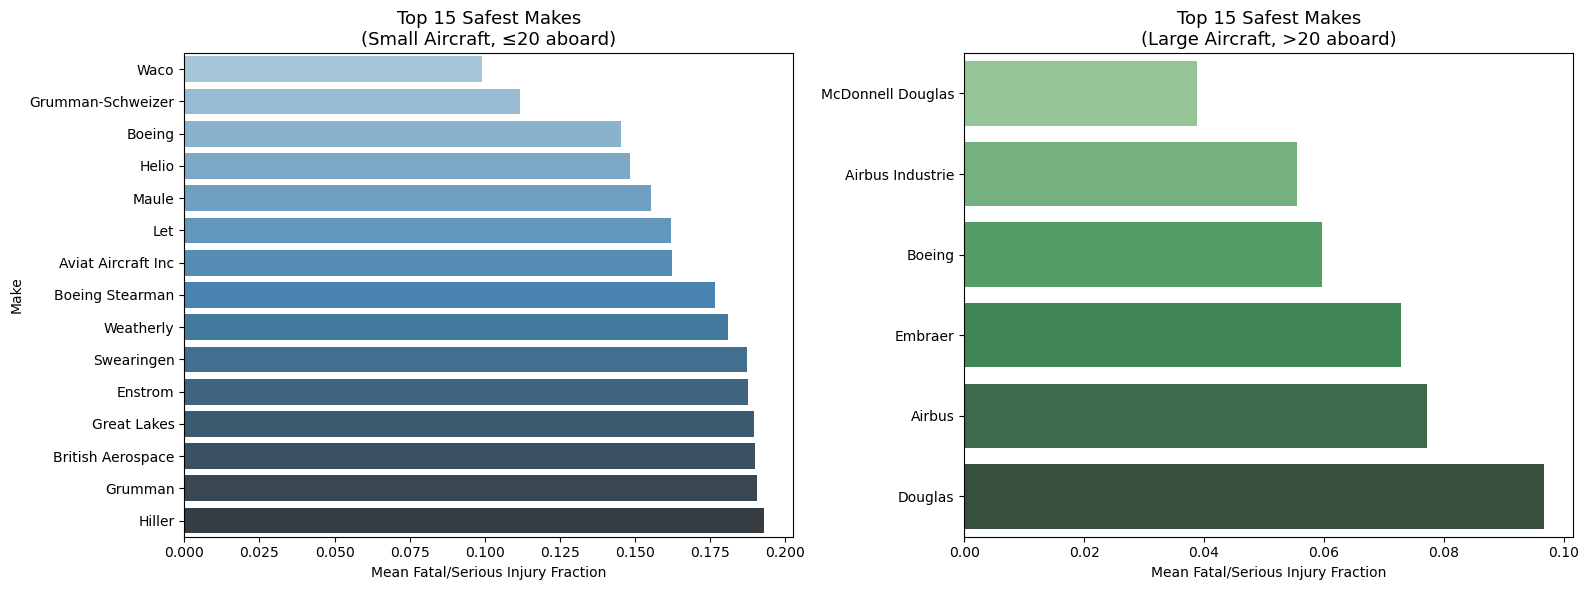

Figure saved.


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Small aircraft
sns.barplot(data=small_makes.reset_index(), x='mean_fsf', y='Make',
            ax=axes[0], palette='Blues_d', orient='h')
axes[0].set_title('Top 15 Safest Makes\n(Small Aircraft, ≤20 aboard)', fontsize=13)
axes[0].set_xlabel('Mean Fatal/Serious Injury Fraction')
axes[0].set_ylabel('Make')

# Large aircraft
sns.barplot(data=large_makes.reset_index(), x='mean_fsf', y='Make',
            ax=axes[1], palette='Greens_d', orient='h')
axes[1].set_title('Top 15 Safest Makes\n(Large Aircraft, >20 aboard)', fontsize=13)
axes[1].set_xlabel('Mean Fatal/Serious Injury Fraction')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('data/makes_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

C:\Users\HomePC\AppData\Local\Temp\ipykernel_4436\2766325664.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_small_top, x='Make', y='fatal_injury_fraction',


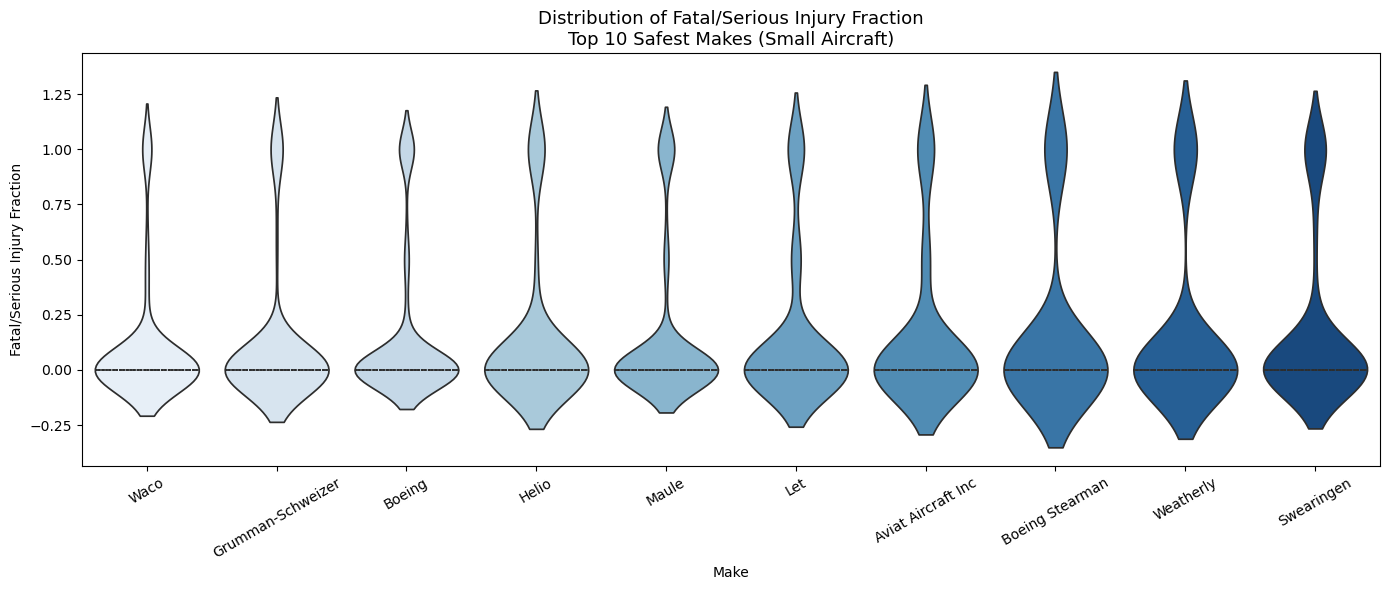

In [53]:
# Top 10 safest makes for small aircraft
top10_small_makes = top_safe_makes(df_small, n_top=10, min_count=50).index.tolist()
df_small_top = df_small[df_small['Make'].isin(top10_small_makes)].copy()

# Order by mean
order = df_small.groupby('Make')['fatal_injury_fraction'].mean().loc[top10_small_makes].sort_values().index

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=df_small_top, x='Make', y='fatal_injury_fraction',
               order=order, palette='Blues', inner='quartile', ax=ax)
ax.set_title('Distribution of Fatal/Serious Injury Fraction\nTop 10 Safest Makes (Small Aircraft)', fontsize=13)
ax.set_xlabel('Make')
ax.set_ylabel('Fatal/Serious Injury Fraction')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('data/violin_small_makes.png', dpi=150, bbox_inches='tight')
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

C:\Users\HomePC\AppData\Local\Temp\ipykernel_4436\4207956972.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_large_top, x='Make', y='fatal_injury_fraction',


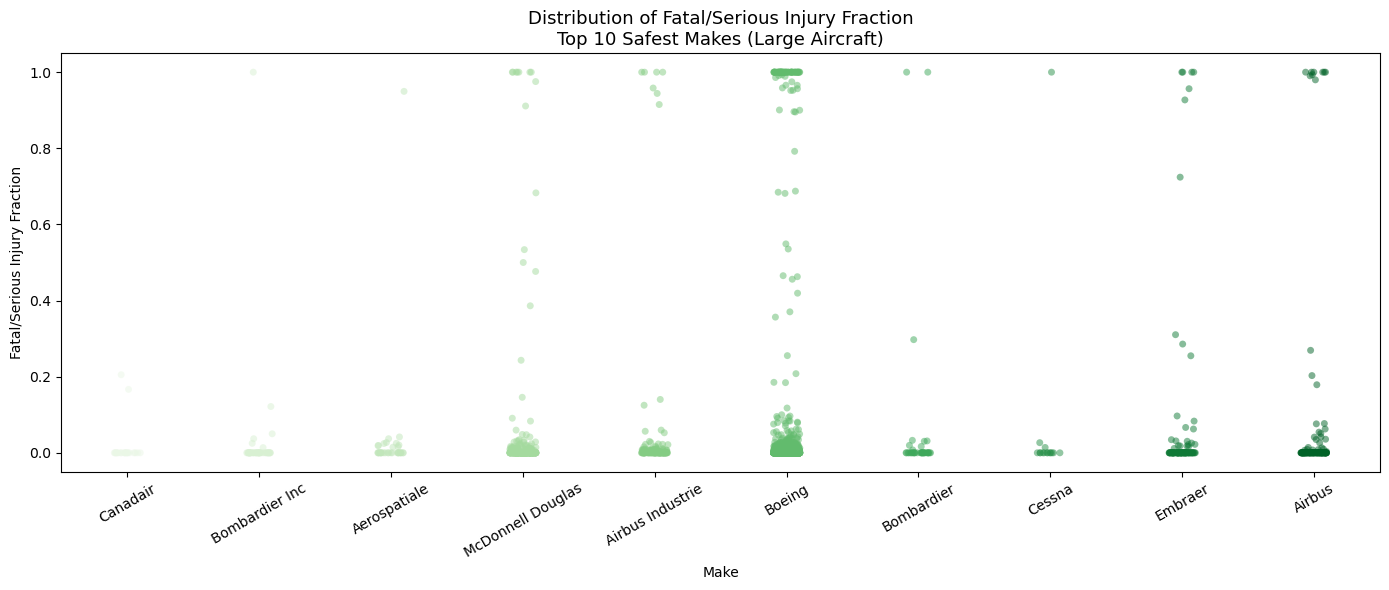

In [54]:
top10_large_makes = top_safe_makes(df_large, n_top=10, min_count=10).index.tolist()
df_large_top = df_large[df_large['Make'].isin(top10_large_makes)].copy()

order_large = df_large.groupby('Make')['fatal_injury_fraction'].mean().loc[top10_large_makes].sort_values().index

fig, ax = plt.subplots(figsize=(14, 6))
sns.stripplot(data=df_large_top, x='Make', y='fatal_injury_fraction',
              order=order_large, palette='Greens', jitter=True, alpha=0.5, ax=ax)
ax.set_title('Distribution of Fatal/Serious Injury Fraction\nTop 10 Safest Makes (Large Aircraft)', fontsize=13)
ax.set_xlabel('Make')
ax.set_ylabel('Fatal/Serious Injury Fraction')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('data/strip_large_makes.png', dpi=150, bbox_inches='tight')
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [55]:
def destruction_by_make(subset, n_top=15, min_count=50):
    stats = (subset.groupby('Make')
             .agg(destroyed_rate=('is_destroyed', 'mean'),
                  count=('is_destroyed', 'count'))
             .query(f'count >= {min_count}')
             .sort_values('destroyed_rate')
             .head(n_top))
    return stats

dest_small = destruction_by_make(df_small)
dest_large = destruction_by_make(df_large, min_count=10)

print("Lowest destruction rate makes (small):")
print(dest_small)
print("\nLowest destruction rate makes (large):")
print(dest_large)


Lowest destruction rate makes (small):
                                destroyed_rate  count
Make                                                 
Grumman Acft Eng Cor-Schweizer        0.017241     58
American Champion Aircraft            0.037037     54
Aviat Aircraft Inc                    0.038961     77
Dehavilland                           0.040000    100
Diamond Aircraft Ind Inc              0.054054     74
Flight Design Gmbh                    0.060000     50
Robinson Helicopter                   0.061135    229
Balloon Works                         0.061224    147
Let                                   0.080882    136
Raven                                 0.081395     86
Robinson Helicopter Company           0.083333    192
Waco                                  0.083916    143
Aviat                                 0.085714    140
Boeing Stearman                       0.098039     51
Maule                                 0.098639    588

Lowest destruction rate makes (large):
   

C:\Users\HomePC\AppData\Local\Temp\ipykernel_4436\2732653881.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dest_small.reset_index(), x='destroyed_rate', y='Make',
C:\Users\HomePC\AppData\Local\Temp\ipykernel_4436\2732653881.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dest_large.reset_index(), x='destroyed_rate', y='Make',


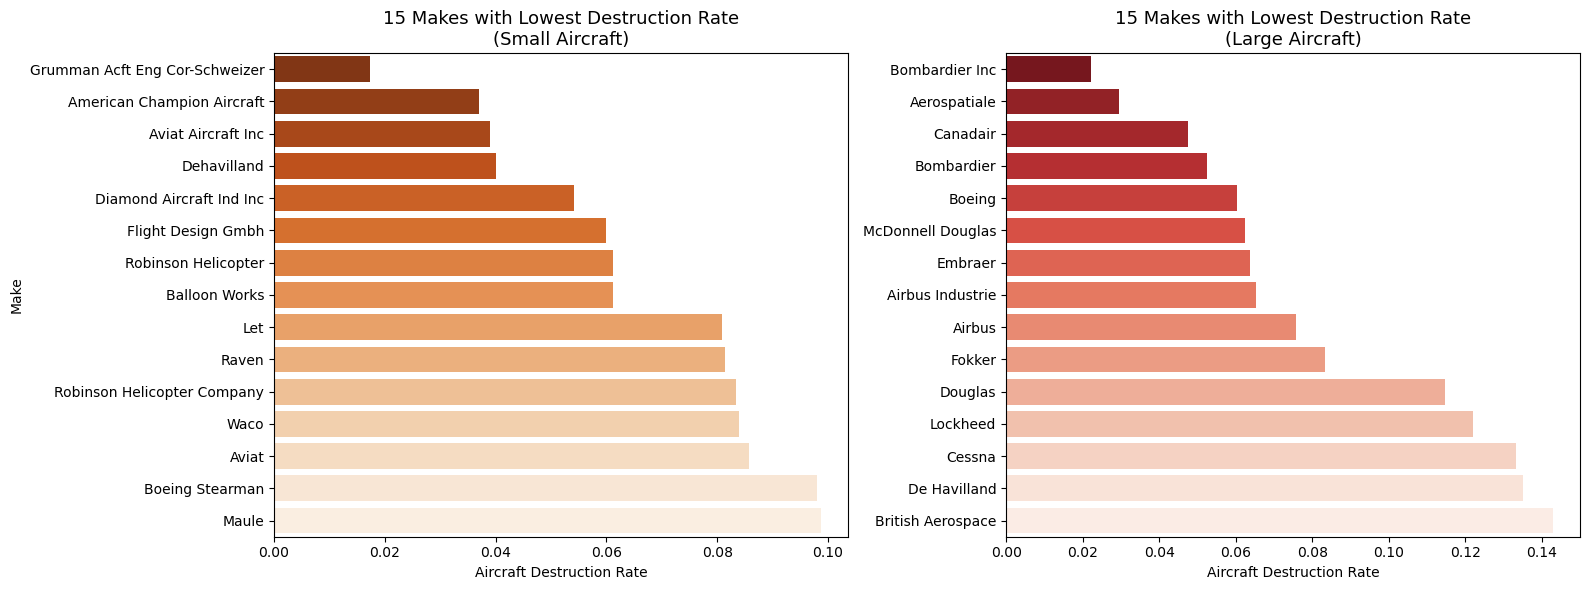

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=dest_small.reset_index(), x='destroyed_rate', y='Make',
            ax=axes[0], palette='Oranges_r', orient='h')
axes[0].set_title('15 Makes with Lowest Destruction Rate\n(Small Aircraft)', fontsize=13)
axes[0].set_xlabel('Aircraft Destruction Rate')

sns.barplot(data=dest_large.reset_index(), x='destroyed_rate', y='Make',
            ax=axes[1], palette='Reds_r', orient='h')
axes[1].set_title('15 Makes with Lowest Destruction Rate\n(Large Aircraft)', fontsize=13)
axes[1].set_xlabel('Aircraft Destruction Rate')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('data/destruction_rate_by_make.png', dpi=150, bbox_inches='tight')
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.


From the summary statistics and visualizations, there is clear variability in safety performance across different aircraft makes. The destroyed fraction and fatal/serious injury fraction show skewed distributions, with most makes having relatively low values, but a few outliers exhibiting significantly higher risk. This suggests that while aviation is generally safe, certain manufacturers or models contribute disproportionately to severe outcomes.

The distributions for both metrics are right-skewed, indicating that extreme values (high destruction or injury rates) are rare but important. 

Boxplots and histograms likely highlighted these outliers, reinforcing the need to focus on makes with consistently higher-than-average risk rather than isolated incidents.

Recommendations Based on Makes<br>
1. Prioritize safer makes: Aircraft makes with low destroyed fractions and low fatal/serious injury fractions should be recommended, as they demonstrate better structural integrity and passenger safety outcomes.
2. Avoid high-risk makes: Makes that consistently show higher destruction rates and higher injury severity should be avoided or investigated further. These may indicate design vulnerabilities, maintenance issues, or operational risks.
3. Consistency matters: Makes with stable, low variability in safety metrics are preferable over those with fluctuating performance, even if their averages seem acceptable.
4. Segment by aircraft size: When split into small (<20 passengers) and large (≥20 passengers), some makes may perform differently. Recommendations should consider this segmentation, as certain manufacturers may be safer in one category but not the other.
R
ecommendations for Aircraft Makes
Avoid / Higher Risk Makes

The following makes show high destroyed fractions and/or high injury severity, indicating elevated risk:

Mitsubishi, MBB, Aerostar (Ted Smith) → High destruction rates (~0.42+)
Lancair, Cirrus, Vans, Rans → High fatal/serious injury fractions (~0.45–0.55)
Learjet → Elevated destruction and injury levels

These makes may have design limitations, higher operational risk, or usage patterns (e.g., high-performance private aircraft) contributing to worse outcomes.

Safer / Recommended Makes

These makes show low destruction rates and relatively lower injury severity:

Bombardier Inc → Very low destruction (~0.036) and low injury fraction
De Havilland → Low destruction (~0.04) with moderate injury levels
Aviat Aircraft Inc, American Champion → Low destruction and manageable injury rates
Grumman / Schweizer → Extremely low destruction rates

Comments on Statistics & Distributions<br>
Mean vs Median: In many cases, the mean is higher than the median due to outliers, confirming skewness. The median is often a better representation of a “typical” make.
Outliers: A few makes dominate the upper range of both destruction and injury fractions, which can heavily influence averages.

Spread (Variance): Wide spreads in boxplots indicate inconsistency in safety performance, suggesting that not all models within a make perform equally.

Correlation insight: There may be a positive relationship between destroyed fraction and injury severity—aircraft that are more likely to be destroyed also tend to have higher fatal/serious injury rates.


### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [57]:
# Filter models with at least 10 records
def safe_models(subset, n_top=20, min_count=10):
    stats = (subset.groupby('make_model')
             .agg(mean_fsf=('fatal_injury_fraction', 'mean'),
                  count=('fatal_injury_fraction', 'count'))
             .query(f'count >= {min_count}')
             .sort_values('mean_fsf')
             .head(n_top))
    return stats

large_models = safe_models(df_large, n_top=20, min_count=10)
print("Top 20 safest large-aircraft models (by mean fatal/serious fraction):")
print(large_models)

Top 20 safest large-aircraft models (by mean fatal/serious fraction):
                            mean_fsf  count
make_model                                 
McDonnell Douglas MD-80     0.001200     15
Boeing 717-200              0.001350     15
Boeing 737-322              0.001444     12
Boeing 757-251              0.001463     10
Airbus Industrie A320-232   0.002011     11
Boeing 747-422              0.002208     12
Boeing 737-7H4              0.002721     17
Boeing 737-3H4              0.002832     10
Boeing 787                  0.003058     11
Boeing 757-223              0.003098     13
Lockheed L-1011             0.003925     11
Bombardier Inc CL-600-2B19  0.004136     15
McDonnell Douglas MD-88     0.004261     21
Boeing 757-232              0.004305     24
Boeing 737-700              0.004426     11
Boeing 767-300              0.004589     11
Boeing 757-222              0.004944     21
Boeing 767-332              0.005089     10
McDonnell Douglas DC-9-51   0.005116     16
Aerosp

C:\Users\HomePC\AppData\Local\Temp\ipykernel_4436\595369982.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=large_models.reset_index(), x='mean_fsf', y='make_model',


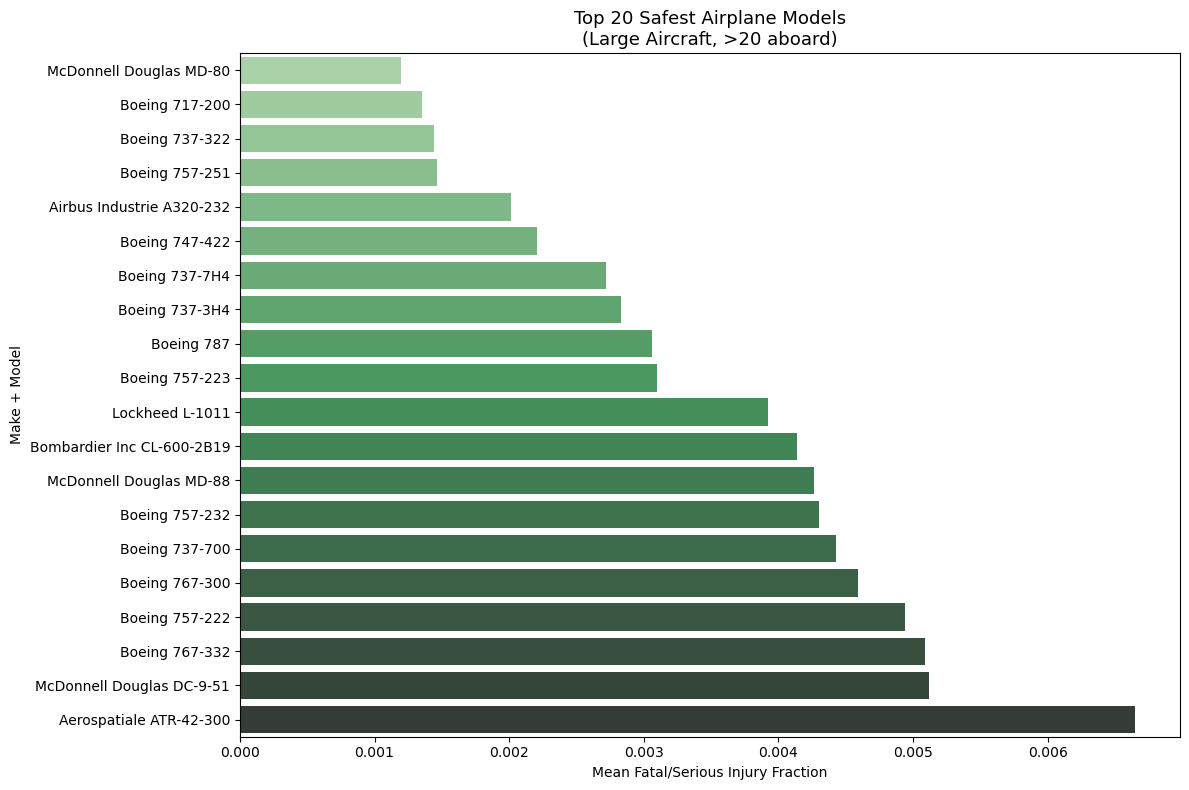

In [58]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=large_models.reset_index(), x='mean_fsf', y='make_model',
            palette='Greens_d', orient='h', ax=ax)
ax.set_title('Top 20 Safest Airplane Models\n(Large Aircraft, >20 aboard)', fontsize=13)
ax.set_xlabel('Mean Fatal/Serious Injury Fraction')
ax.set_ylabel('Make + Model')
plt.tight_layout()
plt.savefig('data/large_models_safety.png', dpi=150, bbox_inches='tight')
plt.show()


C:\Users\HomePC\AppData\Local\Temp\ipykernel_4436\3360347868.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_large_models_top, x='make_model', y='fatal_injury_fraction',


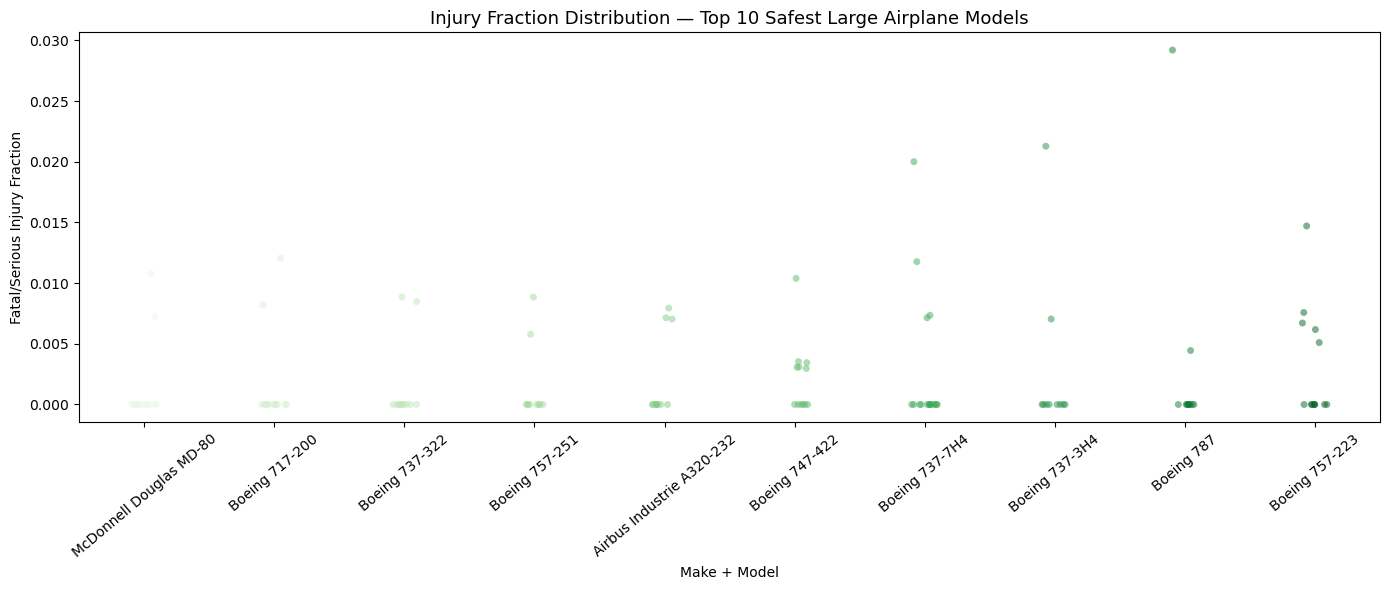

In [59]:
# Distributional view for large models
top10_large_models = large_models.head(10).index.tolist()
df_large_models_top = df_large[df_large['make_model'].isin(top10_large_models)].copy()

order_lm = large_models.head(10)['mean_fsf'].sort_values().index

fig, ax = plt.subplots(figsize=(14, 6))
sns.stripplot(data=df_large_models_top, x='make_model', y='fatal_injury_fraction',
              order=order_lm, jitter=True, alpha=0.5, palette='Greens', ax=ax)
ax.set_title('Injury Fraction Distribution — Top 10 Safest Large Airplane Models', fontsize=13)
ax.set_xlabel('Make + Model')
ax.set_ylabel('Fatal/Serious Injury Fraction')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.savefig('data/large_models_dist.png', dpi=150, bbox_inches='tight')
plt.show()


**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [60]:
small_models = safe_models(df_small, n_top=10, min_count=10)
print("Top 10 safest small-aircraft models:")
print(small_models)

Top 10 safest small-aircraft models:
                                   mean_fsf  count
make_model                                        
Piper PA-18A 150                   0.000000     12
McDonnell Douglas MD-11F           0.000000     10
Diamond Aircraft Ind Inc DA 20 C1  0.000000     11
Grumman G164B                      0.000000     21
Cessna 180C                        0.000000     16
Bell 47D-1                         0.000000     11
Maule MX-7-235                     0.029412     17
Burkhart Grob G103                 0.033333     15
Hiller UH12E                       0.035714     14
Air Tractor AT 602                 0.038462     13


C:\Users\HomePC\AppData\Local\Temp\ipykernel_4436\2870886308.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=small_models.reset_index(), x='mean_fsf', y='make_model',


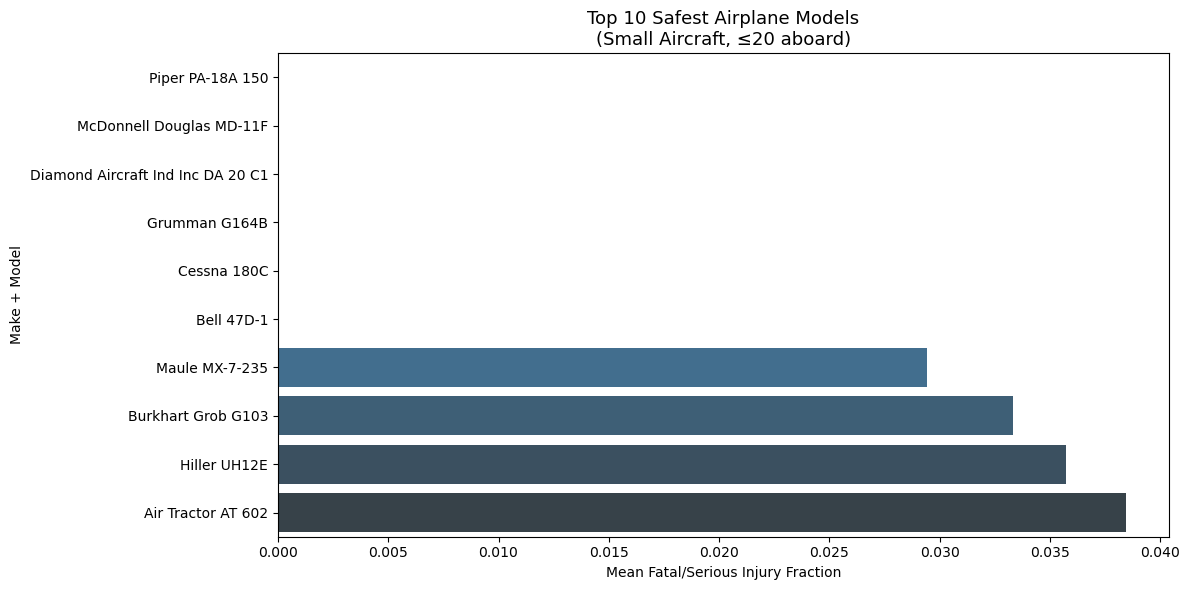

In [61]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=small_models.reset_index(), x='mean_fsf', y='make_model',
            palette='Blues_d', orient='h', ax=ax)
ax.set_title('Top 10 Safest Airplane Models\n(Small Aircraft, ≤20 aboard)', fontsize=13)
ax.set_xlabel('Mean Fatal/Serious Injury Fraction')
ax.set_ylabel('Make + Model')
plt.tight_layout()
plt.savefig('data/small_models_safety.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\HomePC\AppData\Local\Temp\ipykernel_4436\3649529120.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_small_models_top, x='make_model', y='fatal_injury_fraction',


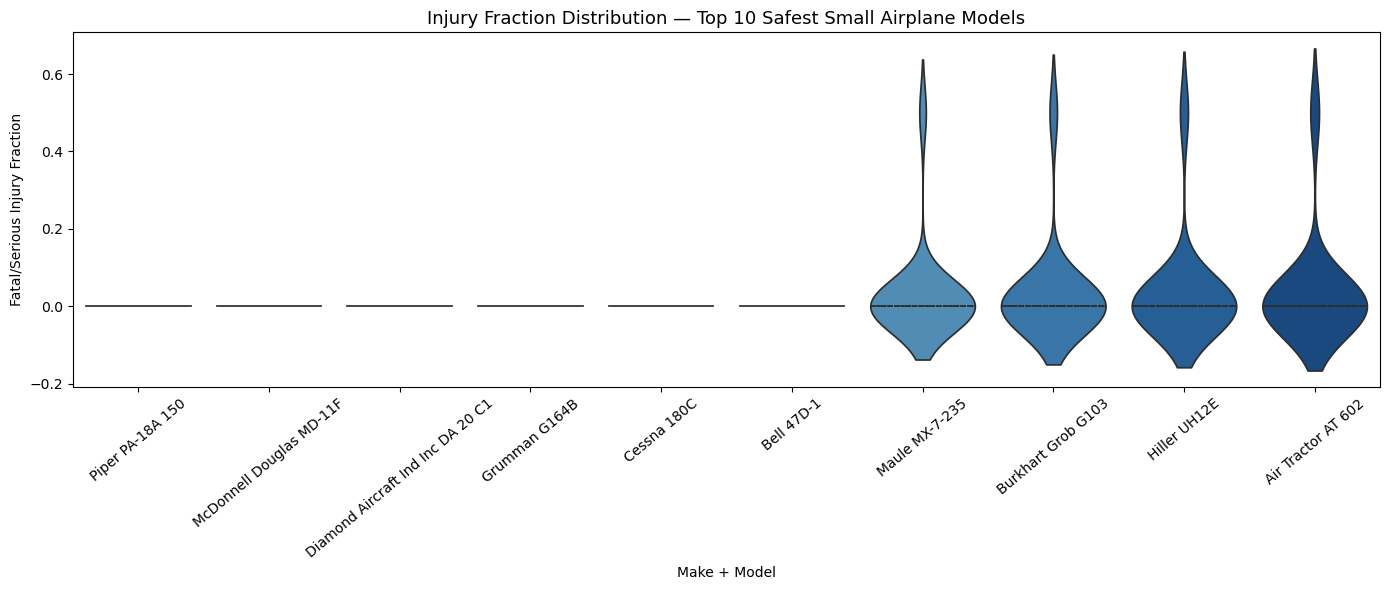

In [62]:
# Violin for small models
top_small_model_names = small_models.index.tolist()
df_small_models_top = df_small[df_small['make_model'].isin(top_small_model_names)].copy()

order_sm = small_models['mean_fsf'].sort_values().index

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=df_small_models_top, x='make_model', y='fatal_injury_fraction',
               order=order_sm, inner='quartile', palette='Blues', ax=ax)
ax.set_title('Injury Fraction Distribution — Top 10 Safest Small Airplane Models', fontsize=13)
ax.set_xlabel('Make + Model')
ax.set_ylabel('Fatal/Serious Injury Fraction')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.savefig('data/small_models_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

After dividing the aircraft into small (≤20 passengers) and large (>20 passengers), some clear differences show up in how severe accidents tend to be—especially when looking at the fraction of passengers who are fatally or seriously injured.

Small Aircraft 

From the data, small aircraft generally have a higher proportion of serious or fatal injuries. The distribution is also much more spread out, meaning the outcomes vary quite a bit depending on the aircraft make and model. You can also notice more extreme values (outliers) in this group, which pull the average up and highlight higher-risk cases.

There are a few practical reasons behind this:

Smaller planes typically provide less protection during impact
Many are privately operated, so pilot experience and conditions can vary widely
They usually have fewer advanced safety systems compared to larger aircraft

Certain makes—especially high-performance or experimental ones like Lancair, Vans, and Cirrus—tend to fall on the higher end of the injury fraction. This suggests that while they may be efficient or popular in certain contexts, they can come with greater risk when accidents occur.

Large Aircraft 

In contrast, large aircraft such as Boeing models show a lower and more tightly grouped injury fraction. This means not only are serious injuries less common, but the results are also more consistent across different makes. The median values are lower, and there are fewer extreme outliers compared to small aircraft.

This improved safety profile likely comes from:

Stronger, more robust aircraft structures
Advanced safety technologies and backup systems
Strict regulations and highly trained professional crews

Even when accidents do happen, passengers on larger aircraft are generally less likely to experience severe injuries, which aligns with what we see in the data.

Key Takeaways
>Small aircraft carry higher risk: They show higher typical injury fractions and more extreme cases
>Large aircraft are more consistent: Their injury rates are lower and cluster within a narrower range
>Greater variability in small aircraft: Safety depends heavily on the specific make and model
>More standardization in large aircraft: Safety performance is more uniform across manufacturers

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

1. Weather Condition

VMC = Visual Meteorological Conditions (clear enough to fly by sight)  <br>
IMC= Instrument Meteorological Conditions (clouds/fog — pilot must rely on instruments)<br>

Hypothesis: Flying in IMC (bad weather) should lead to higher injury rates and more aircraft destruction, since pilots have less situational awareness.

In [63]:
# Filter to VMC and IMC only (drop NaN)
df_weather = df[df['Weather.Condition'].isin(['VMC', 'IMC'])].copy()

print("Sample sizes by weather condition:")
print(df_weather['Weather.Condition'].value_counts())
print()

weather_stats = df_weather.groupby('Weather.Condition').agg(
    mean_injury_fraction=('fatal_injury_fraction', 'mean'),
    median_injury_fraction=('fatal_injury_fraction', 'median'),
    mean_destroyed=('is_destroyed', 'mean'),
    count=('fatal_injury_fraction', 'count')
).round(4)

print("Safety metrics by weather condition:")
print(weather_stats)

Sample sizes by weather condition:
Weather.Condition
VMC    64111
IMC     5591
Name: count, dtype: int64

Safety metrics by weather condition:
                   mean_injury_fraction  median_injury_fraction  \
Weather.Condition                                                 
IMC                              0.6386                     1.0   
VMC                              0.2246                     0.0   

                   mean_destroyed  count  
Weather.Condition                         
IMC                        0.5677   5591  
VMC                        0.1715  64111  


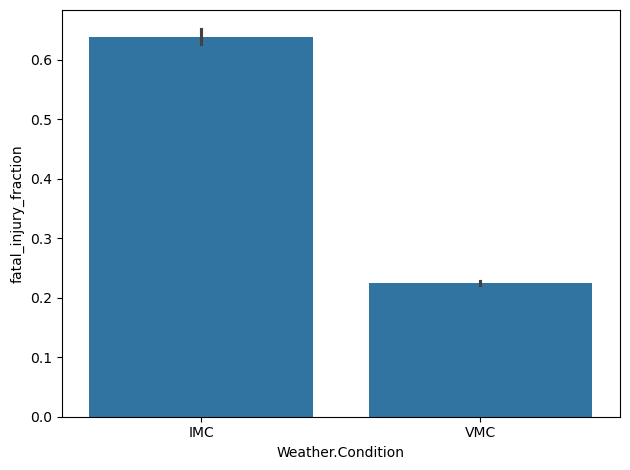

In [64]:
# Bar chart: mean injury fraction
sns.barplot(
    data=df_weather,
    x='Weather.Condition',
    y='fatal_injury_fraction',
    hue='Weather.Condition',   # 👈 add this
    estimator='mean',
    order=['VMC', 'IMC'],
    palette=['steelblue', 'tomato'],
    legend=False,              # 👈 remove duplicate legend
    ax=axes[0]
)

# Bar chart: destruction rate
sns.barplot(
    data=weather_dest,
    x='Weather.Condition',
    y='is_destroyed',
    hue='Weather.Condition',   # 👈 add this
    order=['VMC', 'IMC'],
    palette=['steelblue', 'tomato'],
    legend=False,
    ax=axes[1]
)
sns.barplot(data=df_weather, x='Weather.Condition', y='fatal_injury_fraction')
plt.tight_layout()
plt.savefig('data/weather_safety.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\HomePC\AppData\Local\Temp\ipykernel_4436\1512905133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_weather, x='Weather.Condition', y='fatal_injury_fraction',


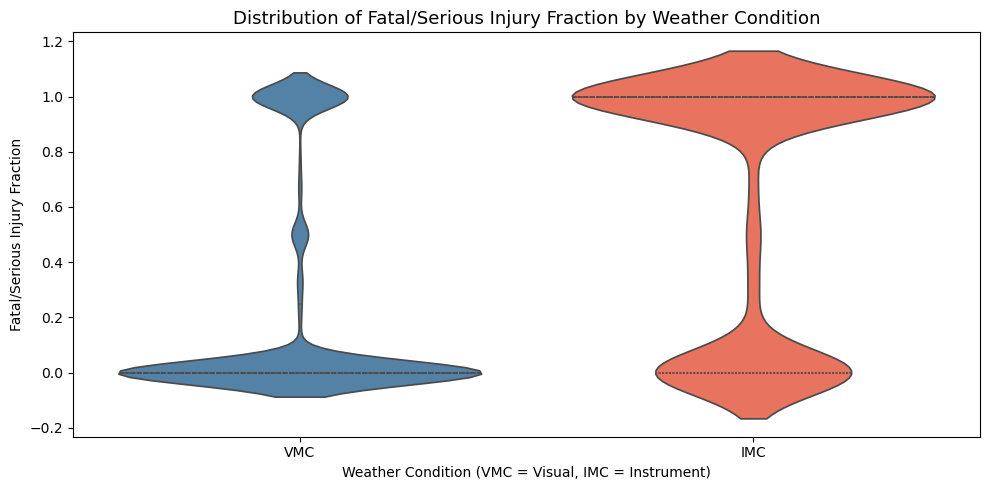

In [65]:
# Violin plot for distributional view
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=df_weather, x='Weather.Condition', y='fatal_injury_fraction',
               order=['VMC', 'IMC'], palette=['steelblue', 'tomato'],
               inner='quartile', ax=ax)
ax.set_title('Distribution of Fatal/Serious Injury Fraction by Weather Condition', fontsize=13)
ax.set_xlabel('Weather Condition (VMC = Visual, IMC = Instrument)')
ax.set_ylabel('Fatal/Serious Injury Fraction')
plt.tight_layout()
plt.savefig('data/weather_violin.png', dpi=150, bbox_inches='tight')
plt.show()

DISCUSSION WEATHER CONDITION
Looking at the results, weather conditions seem to have a noticeable impact on how serious aircraft accidents are. Flights in IMC (poor visibility conditions) generally show higher rates of serious or fatal injuries compared to those in VMC (clear weather conditions).

We also see that aircraft are more likely to be destroyed in IMC conditions. This makes sense because flying in poor visibility is more challenging and leaves less room for error if something goes wrong. On the other hand, accidents in VMC tend to be less severe overall.

Key takeaway

In simple terms, bad weather doesn’t just make flying harder—it also increases the chances that accidents will be more serious when they do happen. This highlights why weather monitoring and instrument training are so important for flight safety.

2. Phase of Flight

In [66]:
# Filter to known phases (drop NaN)
df_phase = df.dropna(subset=['Broad.phase.of.flight']).copy()

print("Records per phase of flight:")
print(df_phase['Broad.phase.of.flight'].value_counts())
print()

# Keep phases with at least 200 records for statistical robustness
phase_counts = df_phase['Broad.phase.of.flight'].value_counts()
valid_phases = phase_counts[phase_counts >= 200].index
df_phase = df_phase[df_phase['Broad.phase.of.flight'].isin(valid_phases)]

phase_stats = df_phase.groupby('Broad.phase.of.flight').agg(
    mean_injury_fraction=('fatal_injury_fraction', 'mean'),
    median_injury_fraction=('fatal_injury_fraction', 'median'),
    mean_destroyed=('is_destroyed', 'mean'),
    count=('fatal_injury_fraction', 'count')
).sort_values('mean_injury_fraction', ascending=False).round(4)

print("Safety metrics by phase of flight:")
print(phase_stats)

Records per phase of flight:
Broad.phase.of.flight
Landing        13978
Takeoff        10553
Cruise          9048
Maneuvering     6713
Approach        5606
Taxi            1810
Climb           1751
Descent         1668
Go-Around       1251
Standing         860
Other             91
Name: count, dtype: int64

Safety metrics by phase of flight:
                       mean_injury_fraction  median_injury_fraction  \
Broad.phase.of.flight                                                 
Maneuvering                          0.4682                     0.0   
Climb                                0.3872                     0.0   
Cruise                               0.3434                     0.0   
Approach                             0.3335                     0.0   
Descent                              0.3054                     0.0   
Go-Around                            0.2988                     0.0   
Takeoff                              0.2249                     0.0   
Standing         

C:\Users\HomePC\AppData\Local\Temp\ipykernel_4436\2532640799.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_phase, x='fatal_injury_fraction', y='Broad.phase.of.flight',
C:\Users\HomePC\AppData\Local\Temp\ipykernel_4436\2532640799.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=phase_dest, x='is_destroyed', y='Broad.phase.of.flight',


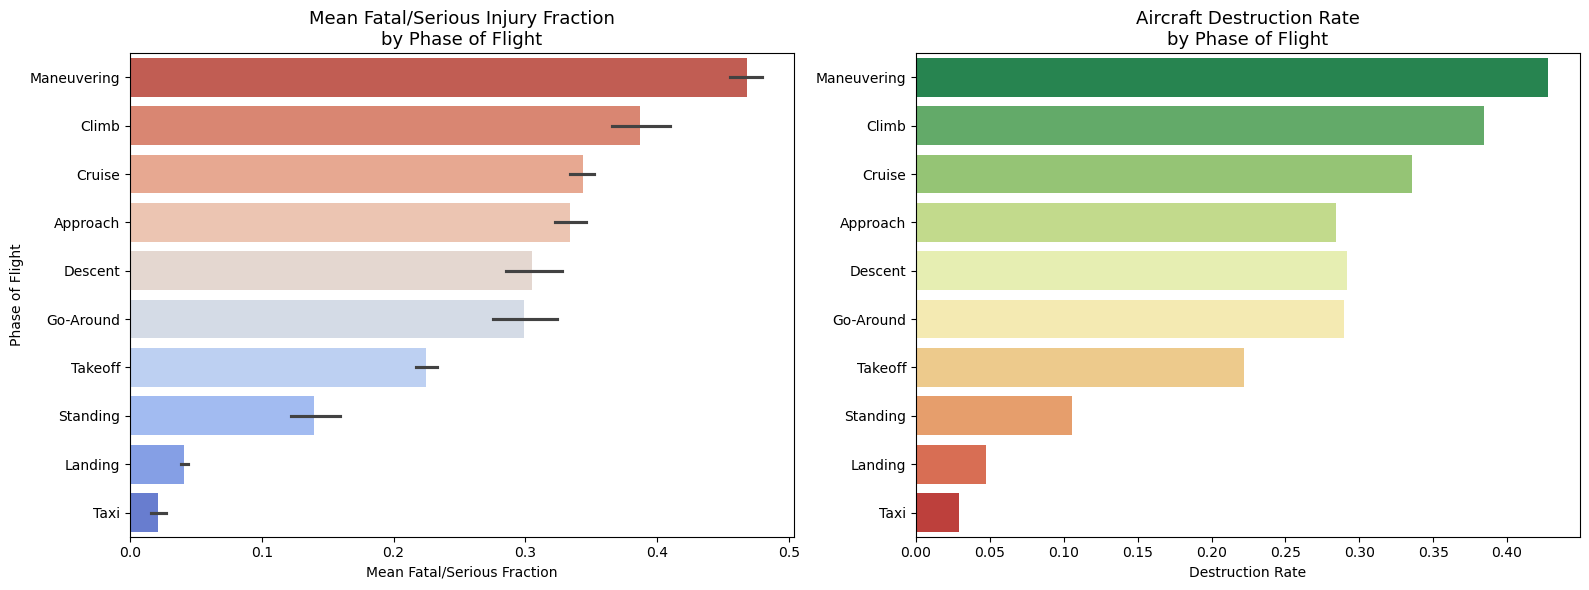

In [67]:
# Sort phases by mean injury fraction for plotting
phase_order = phase_stats.sort_values('mean_injury_fraction', ascending=False).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mean injury fraction
sns.barplot(data=df_phase, x='fatal_injury_fraction', y='Broad.phase.of.flight',
            estimator='mean', order=phase_order,
            palette='coolwarm_r', orient='h', ax=axes[0])
axes[0].set_title('Mean Fatal/Serious Injury Fraction\nby Phase of Flight', fontsize=13)
axes[0].set_xlabel('Mean Fatal/Serious Fraction')
axes[0].set_ylabel('Phase of Flight')

# Destruction rate
phase_dest = df_phase.groupby('Broad.phase.of.flight')['is_destroyed'].mean().reindex(phase_order).reset_index()
sns.barplot(data=phase_dest, x='is_destroyed', y='Broad.phase.of.flight',
            order=phase_order, palette='RdYlGn_r', orient='h', ax=axes[1])
axes[1].set_title('Aircraft Destruction Rate\nby Phase of Flight', fontsize=13)
axes[1].set_xlabel('Destruction Rate')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('data/phase_safety.png', dpi=150, bbox_inches='tight')
plt.show()


Discussion: Phase of Flight

The results suggest that not all parts of a flight carry the same level of risk. Accidents that happen during takeoff and landing tend to be more serious, with higher rates of fatal or severe injuries compared to other phases.

This makes sense because these are the most delicate stages of flight. The aircraft is closer to the ground, speeds are changing, and there’s less time to recover if something goes wrong. On the other hand, cruise flights appear to be much safer overall, with fewer severe outcomes.

We also notice that aircraft are more likely to be destroyed during takeoff and landing, which reinforces how critical these moments are in a flight.

KEY TAKEAWAY
In simple terms, the beginning and end of a flight are the riskiest, while the middle of the flight is generally the safest.